In [73]:
from calibrationnet.db import get_session
from sqlalchemy import select
from calibrationnet.models import RunPixel
from calibrationnet.models import TrapFilterOutput
import numpy as np
import matplotlib.pyplot as plt
import fit_functions as f
from lmfit import Parameters
import pylab as py
from importlib import reload
from scipy.signal import find_peaks

In [4]:
with get_session() as session:
    runpixel = session.execute(select(RunPixel).where(RunPixel.run_number==8622,RunPixel.pixel_number==60)).scalars().all()
    runpixel_id = runpixel[0].id
    raw_energy = session.execute(select(TrapFilterOutput.energies).where(TrapFilterOutput.run_pixel_id==runpixel_id)).scalars().all()

In [5]:
histogram = np.histogram(raw_energy[0],bins = np.arange(0,4500))

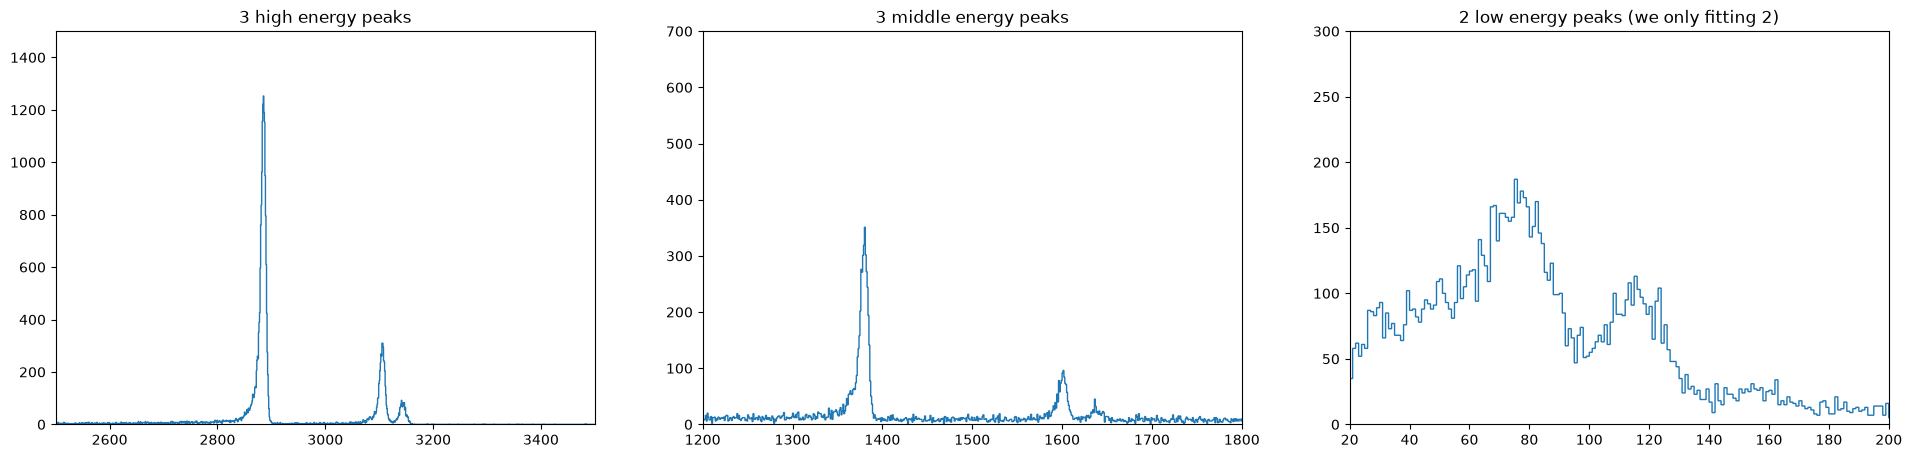

In [15]:
nrows,ncols=8,4
fig = py.figure(figsize=(8*ncols,6*nrows))

ax1=py.subplot(nrows,ncols,1)
ax2=py.subplot(nrows,ncols,2)
ax3=py.subplot(nrows,ncols,3)

ax1.stairs(histogram[0],histogram[1])
ax1.set_xlim(2500,3500)
ax1.set_ylim(0,1500)
ax1.set_title("3 high energy peaks")


ax2.stairs(histogram[0],histogram[1])
ax2.set_xlim(1200,1800)
ax2.set_ylim(0,700)
ax2.set_title("3 middle energy peaks")

ax3.stairs(histogram[0],histogram[1])
ax3.set_xlim(20,200)
ax3.set_ylim(0,300)
ax3.set_title("2 low energy peaks (we only fitting 2)")

plt.show()

# High energy Peak fit (two steps, one for highest intesity peak, second for two lower intensity peaks close together)

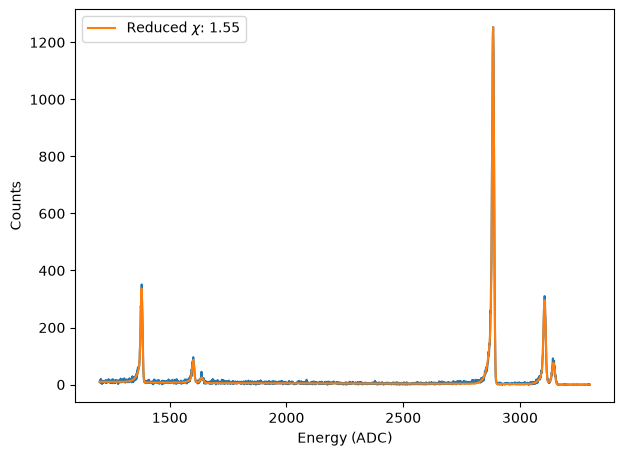

In [146]:
data = raw_energy[0]
lower_bound = 1200
upper_bound = 3300
peak_finder_parameters = (5,None,20,15,1,None,0.5,None)
number_peaks = 6
initial_peak_width_guess = {'sig1':3,'sig2':3,'sig3':3,'sig4':5,'sig5':5,'sig6':5}

nrows,ncols=8,4
fig = py.figure(figsize=(8*ncols,6*nrows))
ax=py.subplot(nrows,ncols,1)

results = f.get_fit(data,lower_bound, upper_bound,peak_finder_parameters,number_peaks,initial_peak_width_guess,plot=True,axis=ax)

In [147]:
results

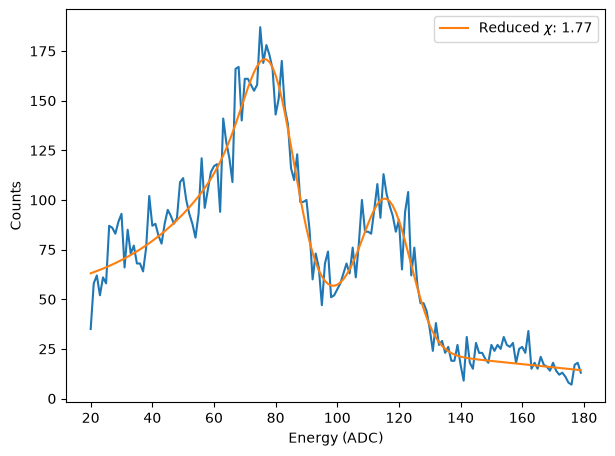

In [129]:
lower_bound = 20
upper_bound = 180
peak_finder_parameters = (5,None,20,15,1,None,0.5,None)
number_peaks = 2
initial_peak_width_guess = {'sig1':3,'sig2':3,'sig3':5}

nrows,ncols=8,4
fig = py.figure(figsize=(8*ncols,6*nrows))
ax=py.subplot(nrows,ncols,1)

results2 = f.get_fit(data,lower_bound, upper_bound,peak_finder_parameters,number_peaks,initial_peak_width_guess,plot=True,axis=ax)